# Heart Attack Risk Detection - Data Exploration

This notebook contains the EDA process for this project. Here you will find different features and preprocess methods for the data to use in this project.

The dataset used was taken from Kaggle, you can find it here:

The attributes included in the dataset are:
* **Patient ID** - Unique identifier for each patient

* **Age** - Age of the patient

* **Sex** - Gender of the patient (Male/Female)

* **Cholesterol** - Cholesterol levels of the patient

* **Blood Pressure** - Blood pressure of the patient (systolic/diastolic)

* **Heart Rate** - Heart rate of the patient

* **Diabetes** - Whether the patient has diabetes (Yes/No)

* **Family History** - Family history of heart-related problems (1: Yes, 0: No)

* **Smoking** - Smoking status of the patient (1: Smoker, 0: Non-smoker)

* **Obesity** - Obesity status of the patient (1: Obese, 0: Not obese)

* **Alcohol Consumption** - Level of alcohol consumption by the patient (None/Light/Moderate/Heavy)

* **Exercise Hours Per Week** - Number of exercise hours per week

* **Diet** - Dietary habits of the patient (Healthy/Average/Unhealthy)

* **Previous Heart Problems** - Previous heart problems of the patient (1: Yes, 0: No)

* **Medication Use** - Medication usage by the patient (1: Yes, 0: No)

* **Stress Level** - Stress level reported by the patient (1-10)

* **Sedentary Hours Per Day** - Hours of sedentary activity per day

* **Income** - Income level of the patient

* **BMI** - Body Mass Index (BMI) of the patient

* **Triglycerides** - Triglyceride levels of the patient

* **Physical Activity Days Per Week** - Days of physical activity per week

* **Sleep Hours Per Day** - Hours of sleep per day

* **Country** - Country of the patient

* **Continent** - Continent where the patient resides

* **Hemisphere** - Hemisphere where the patient resides

* **Heart Attack Risk** - Presence of heart attack risk (1: Yes, 0: No)

In [63]:
import sys
sys.path.append("../src")

import data.make_dataset as data
import visualizations.exploratory as eda

import importlib
importlib.reload(data)
importlib.reload(eda)

<module 'visualizations.exploratory' from 'c:\\Users\\isaac\\Documents\\GitHub\\heart-attack-risk-detection\\notebooks\\../src\\visualizations\\exploratory.py'>

## Load Raw Data

In [ ]:
# Load the raw data
df = data.load_dataset("../data/raw/heart_attack_prediction_dataset.csv")
df

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0


## Exploratoy Data Analysis

In [ ]:
# Displays data features (columns)
df.columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')

Let's verify whether there are missing values.

In [ ]:
# Verify null values
df.isna().sum()

Patient ID                         0
Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                  0
dtype: int64

Let's verify whether there are non-numeric columns.

In [ ]:
# Verify datatypes
df.dtypes

Patient ID                          object
Age                                  int64
Sex                                 object
Cholesterol                          int64
Blood Pressure                      object
Heart Rate                           int64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week            float64
Diet                                object
Previous Heart Problems              int64
Medication Use                       int64
Stress Level                         int64
Sedentary Hours Per Day            float64
Income                               int64
BMI                                float64
Triglycerides                        int64
Physical Activity Days Per Week      int64
Sleep Hours Per Day                  int64
Country                             object
Continent  

Here, we can note several object-type columns. We can drop the ID columns, since it is not important for the analysis. The other will need a transformation.

Now, let's see how many records are for each target class.

In [ ]:
# Verify total values for each target class
df["Heart Attack Risk"].value_counts()

Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

Here, we can see the data is a little unbalanced.

In [8]:
# Show some statistical information about the data
df.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,259.877211,75.021682,0.652288,0.492982,0.896839,0.501426,0.598083,10.014284,0.495835,0.498345,5.469702,5.993690,158263.181901,28.891446,417.677051,3.489672,7.023508,0.358211
std,21.249509,80.863276,20.550948,0.476271,0.499979,0.304186,0.500026,0.490313,5.783745,0.500011,0.500026,2.859622,3.466359,80575.190806,6.319181,223.748137,2.282687,1.988473,0.479502
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,0.000000,1.000000,0.001263,20062.000000,18.002337,30.000000,0.000000,4.000000,0.000000
25%,35.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.981579,0.000000,0.000000,3.000000,2.998794,88310.000000,23.422985,225.500000,2.000000,5.000000,0.000000
50%,54.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.069559,0.000000,0.000000,5.000000,5.933622,157866.000000,28.768999,417.000000,3.000000,7.000000,0.000000
75%,72.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.050018,1.000000,1.000000,8.000000,9.019124,227749.000000,34.324594,612.000000,5.000000,9.000000,1.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,1.000000,10.000000,11.999313,299954.000000,39.997211,800.000000,7.000000,10.000000,1.000000


## Graphical comparisons

First, let's check the age distribution by heart attack risk

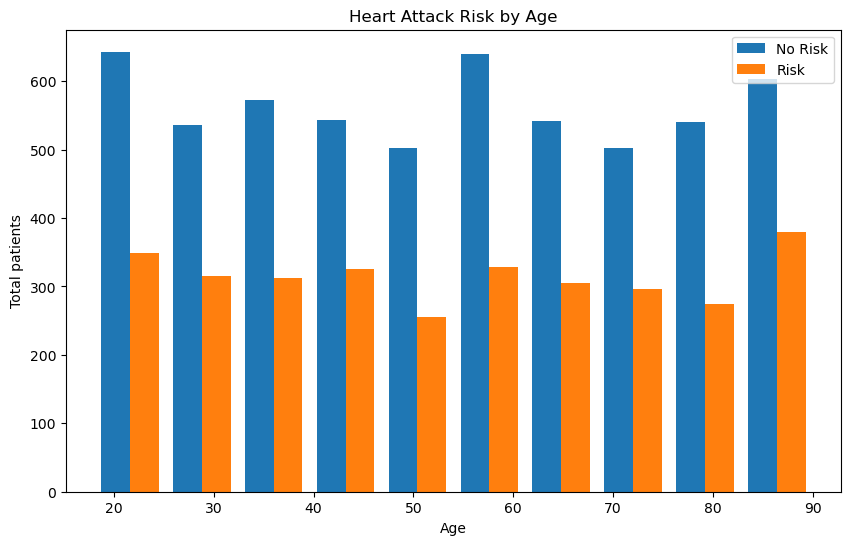

In [64]:
eda.plot_age_hist(df.Age[df["Heart Attack Risk"] == 0], df.Age[df["Heart Attack Risk"] == 1])

Now, let's compare family history with Heart Attack Risk

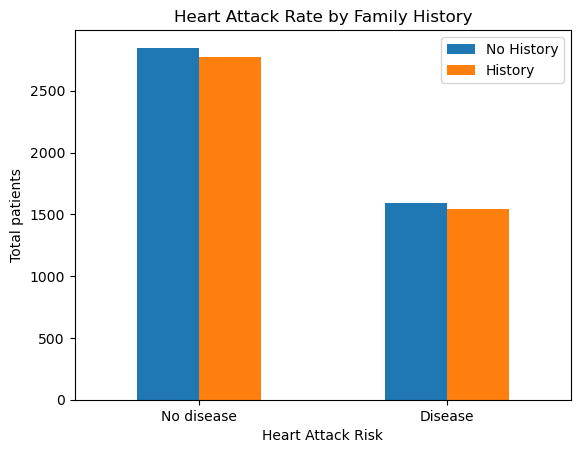

In [65]:
eda.plot_risk_vs_history(df)

Now, let's compare the BMI to the cholesterol levels

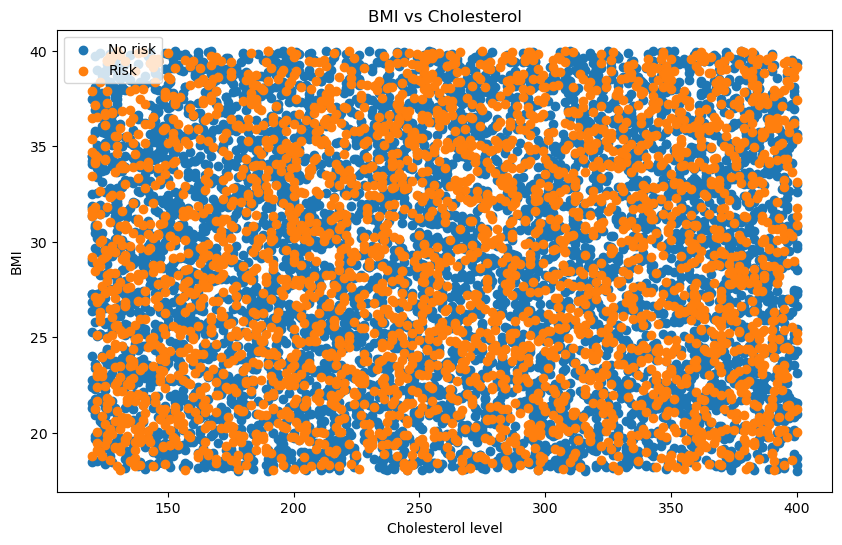

In [66]:
eda.plot_bmi_vs_chol(df)

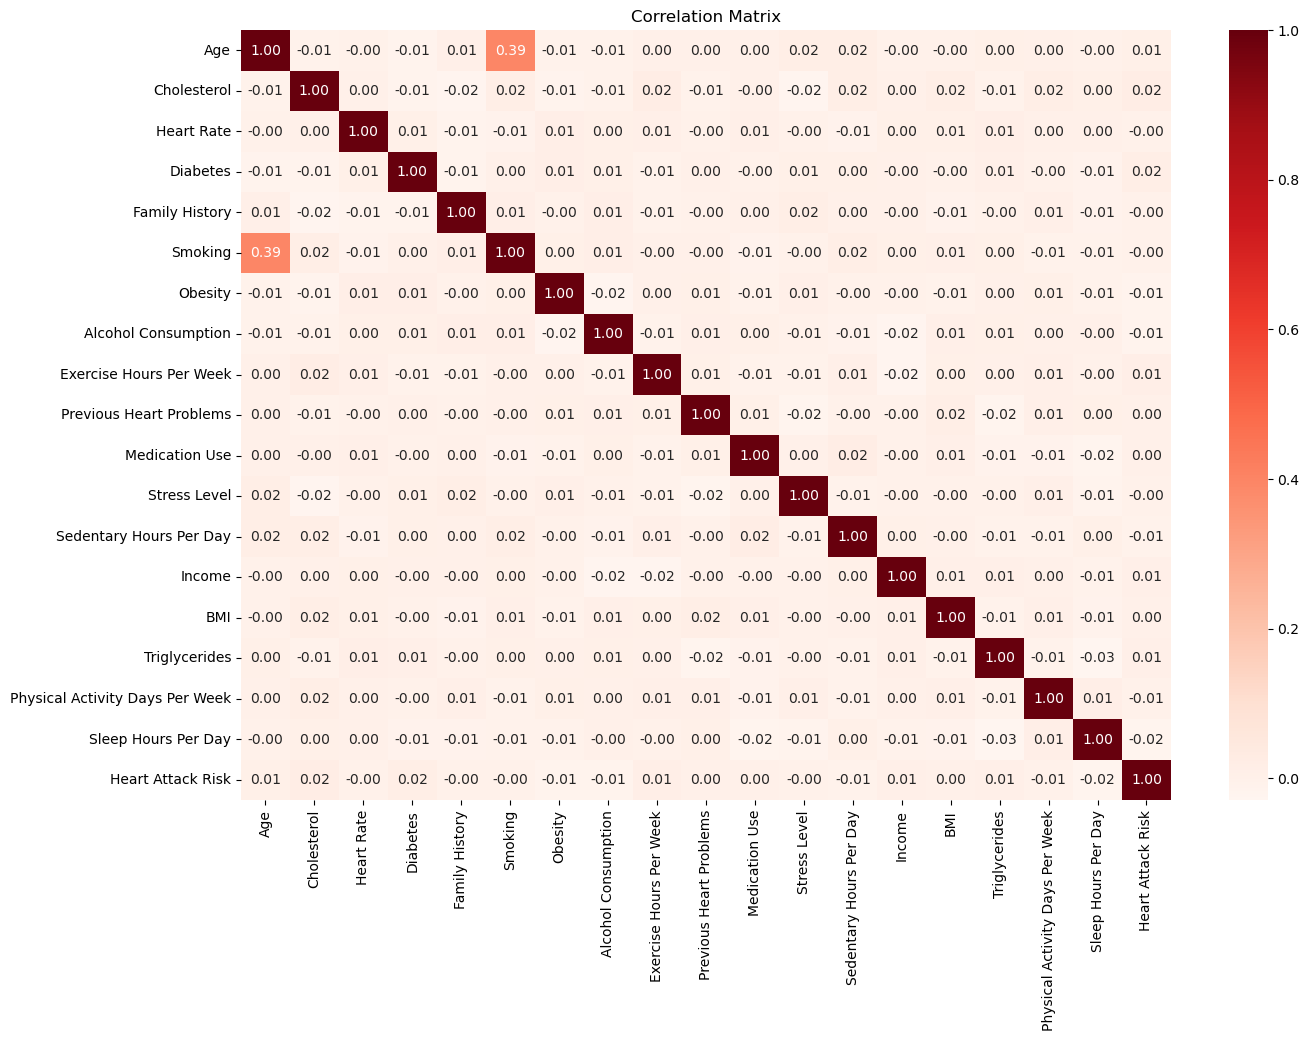

In [67]:
eda.plot_corr_matrix(df)
